In [23]:
# Importing dependencies
from typing import TypedDict
import os

from dotenv import load_dotenv
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph

# Load environment variables
load_dotenv()

# Define the graph state
class CricketState(TypedDict):
    total_ball: int
    total_run: int
    num_six: int
    num_four: int
    boundary_rate: float
    run_rate: float
    summary: str


# Initialize the model
model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="nvidia/nemotron-3.5-lightning:free"
)

# Create the prompt template
prompt = PromptTemplate(
    template=(
        "Answer the question in fewer than 50 words.\n"
        "Question: {ques}"
    ),
    input_variables=["ques"]
)

parser = StrOutputParser()
chain = prompt | model | parser


# Node 1: Collect input values
def input_values(state: CricketState) -> dict:
    total_run = int(input("Enter total runs: "))
    total_ball = int(input("Enter total balls faced: "))
    num_six = int(input("Enter number of sixes: "))
    num_four = int(input("Enter number of fours: "))

    return {
        "total_run": total_run,
        "total_ball": total_ball,
        "num_six": num_six,
        "num_four": num_four
    }


# Node 2: Calculate run rate
def run_rate(state: CricketState) -> dict:
    total_run = state["total_run"]
    total_ball = state["total_ball"]

    if total_ball <= 0:
        raise ValueError("Total balls must be greater than zero.")

    rate = round((total_run / total_ball) * 6, 2)

    return {"run_rate": rate}


# Node 3: Calculate boundary percentage
def boundary_rate(state: CricketState) -> dict:
    num_six = state["num_six"]
    num_four = state["num_four"]
    total_run = state["total_run"]

    if total_run <= 0:
        rate = 0.0
    else:
        boundary_runs = (num_four * 4) + (num_six * 6)
        rate = round((boundary_runs / total_run) * 100, 2)

    return {"boundary_rate": rate}


# Node 4: Generate performance summary
def summary(state: CricketState) -> dict:
    boundary_rate = state["boundary_rate"]
    run_rate = state["run_rate"]

    ques = (
        f"The team has a boundary-run percentage of {boundary_rate}% "
        f"and a run rate of {run_rate} runs per over. "
        "Evaluate the team's current batting performance."
    )

    result = chain.invoke({"ques": ques})

    return {"summary": result}


# Build the graph
graph = StateGraph(CricketState)

graph.add_node("input_values", input_values)
graph.add_node("run_rate", run_rate)
graph.add_node("boundary_rate", boundary_rate)
graph.add_node("summary", summary)

# Define graph edges
graph.add_edge(START, "input_values")

# Run both calculations in parallel
graph.add_edge("input_values", "run_rate")
graph.add_edge("input_values", "boundary_rate")

# Wait for both calculations before generating the summary
graph.add_edge("run_rate", "summary")
graph.add_edge("boundary_rate", "summary")

graph.add_edge("summary", END)



--- Cricket Performance Report ---
Total runs: 100
Total balls: 30
Run rate: 20.0 runs per over
Boundary percentage: 52.0%
Summary: The team exhibits explosively aggressive batting, scoring at 20.0 runs per over with over half the runs coming from boundaries (52.0%). This indicates dominant power-hitting and rapid scoring, though sustainability and strike rotation may be areas to monitor depending on match context.


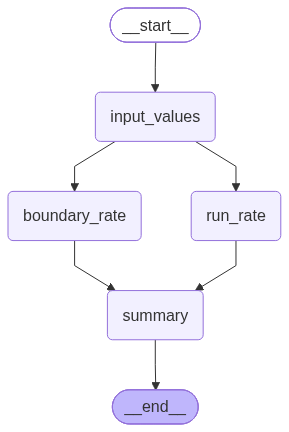

In [24]:
# Compile and execute
workflow = graph.compile()

final_graph = workflow.invoke({})

# Display results
print("\n--- Cricket Performance Report ---")
print(f"Total runs: {final_graph['total_run']}")
print(f"Total balls: {final_graph['total_ball']}")
print(f"Run rate: {final_graph['run_rate']} runs per over")
print(f"Boundary percentage: {final_graph['boundary_rate']}%")
print(f"Summary: {final_graph['summary']}")

display(Image(workflow.get_graph().draw_mermaid_png()))